In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [3]:
# Load dataset
df = pd.read_csv("student_feedback_1000_records (1).csv")


In [4]:
#Displaying datset shape(rows, columns) and first 5 students records

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Records:")
print(df.head())

Dataset Shape:
(959, 9)

First 5 Records:
    Student_Name Roll_No Department Section  Q1_Teaching effectiveness  \
0   Harsha Naidu   R1001        EEE       C                          5   
1  Aditya Sharma   R1002        CSE       C                          4   
2       Teja Rao   R1003      CIVIL       A                          4   
3    Rohan Kumar   R1004        EEE       C                          1   
4     Harsha Rao   R1005         IT       C                          1   

   Q2_Content Quality  Q3_Classroom interaction  Q4_Resource  \
0                   2                         4            1   
1                   4                         4            3   
2                   5                         5            5   
3                   2                         2            4   
4                   1                         4            5   

   Q5_Overall Experience  
0                      1  
1                      3  
2                      2  
3                   

In [5]:
#Finding no.of missing values in each column

print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
Student_Name                 0
Roll_No                      0
Department                   0
Section                      0
Q1_Teaching effectiveness    0
Q2_Content Quality           0
Q3_Classroom interaction     0
Q4_Resource                  0
Q5_Overall Experience        0
dtype: int64


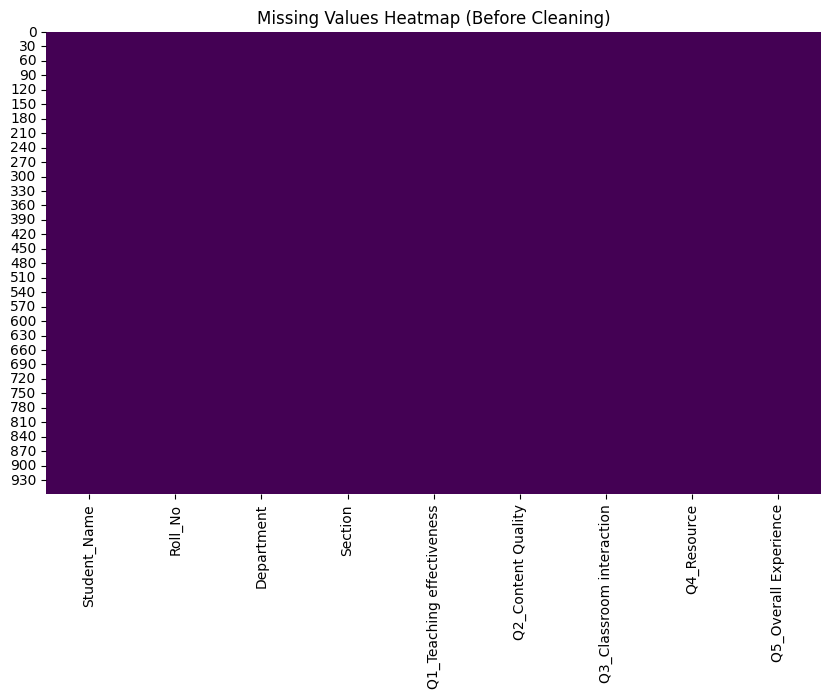

In [6]:
# -------------------------------
# 1. Missing Values
# -------------------------------

# Before Cleaning
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap (Before Cleaning)")
plt.show()

In [7]:
# Cleaning step: fill missing with median for numeric columns
df_clean = df.fillna(df.median(numeric_only=True))
print(df_clean)

      Student_Name Roll_No Department Section  Q1_Teaching effectiveness  \
0     Harsha Naidu   R1001        EEE       C                          5   
1    Aditya Sharma   R1002        CSE       C                          4   
2         Teja Rao   R1003      CIVIL       A                          4   
3      Rohan Kumar   R1004        EEE       C                          1   
4       Harsha Rao   R1005         IT       C                          1   
..             ...     ...        ...     ...                        ...   
954  Vihaan Sharma   R1996       MECH       B                          3   
955  Vihaan Sharma   R1997        ECE       A                          2   
956      Meera Rao   R1998        CSE       A                          1   
957    Meera Kumar   R1999      CIVIL       C                          5   
958    Meera Reddy   R2000      CIVIL       C                          2   

     Q2_Content Quality  Q3_Classroom interaction  Q4_Resource  \
0                    

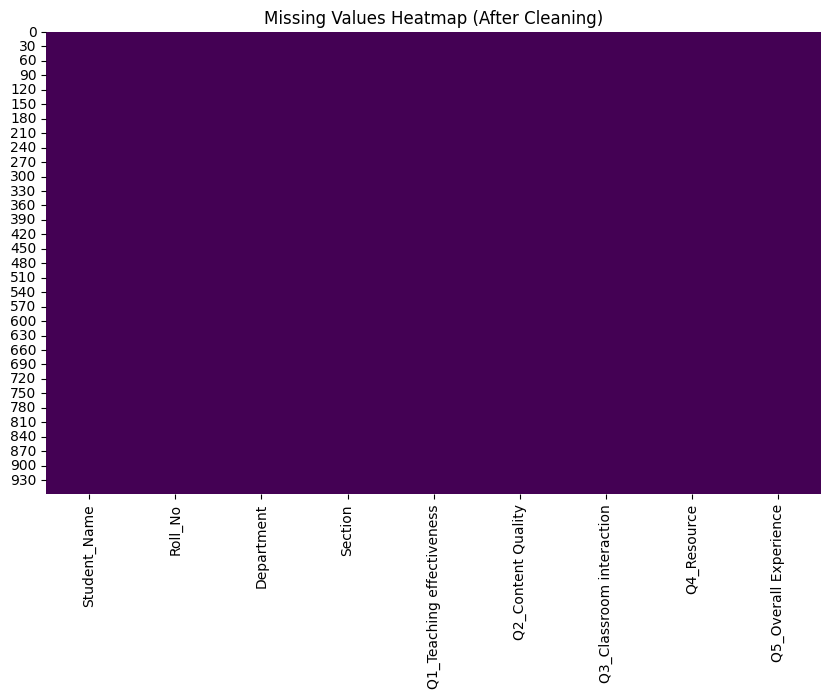

In [8]:
# After Cleaning
plt.figure(figsize=(10,6))
sns.heatmap(df_clean.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap (After Cleaning)")
plt.show()

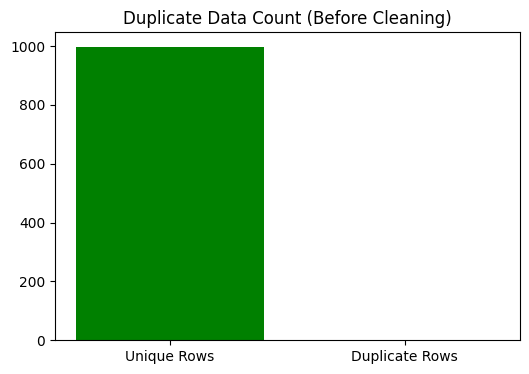

In [ ]:
# Before Cleaning
duplicates = df[df.duplicated()]

plt.figure(figsize=(6,4))

plt.bar(["Unique Rows", "Duplicate Rows"],
        [df.shape[0]-duplicates.shape[0],
        duplicates.shape[0]],
        color=["green","red"])

plt.title("Duplicate Data Count (Before Cleaning)")
plt.show()


In [9]:
# Cleaning step: remove duplicates
df_clean = df_clean.drop_duplicates()

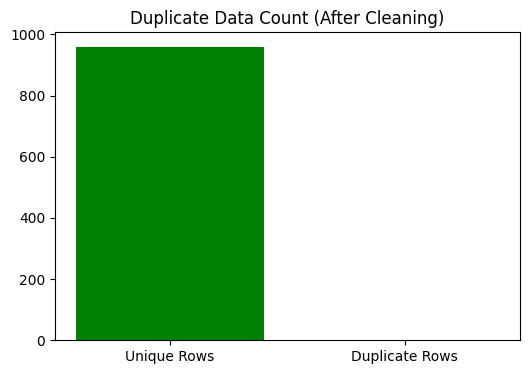

In [10]:
# After Cleaning
duplicates_after = df_clean[df_clean.duplicated()]
plt.figure(figsize=(6,4))
plt.bar(["Unique Rows", "Duplicate Rows"],
        [df_clean.shape[0]-duplicates_after.shape[0],
        duplicates_after.shape[0]],
        color=["green","red"])

plt.title("Duplicate Data Count (After Cleaning)")
plt.show()

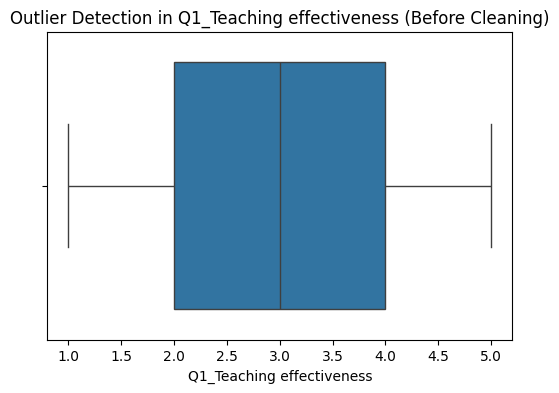

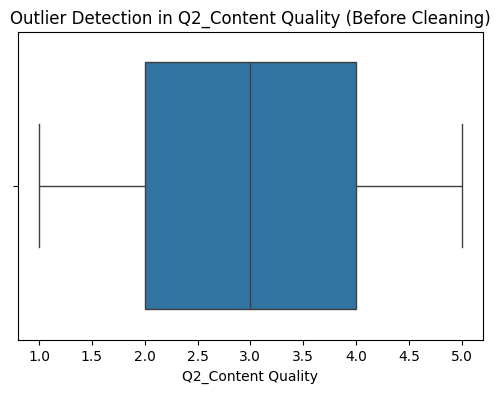

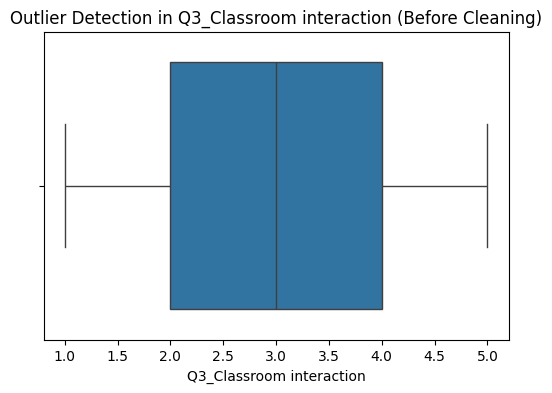

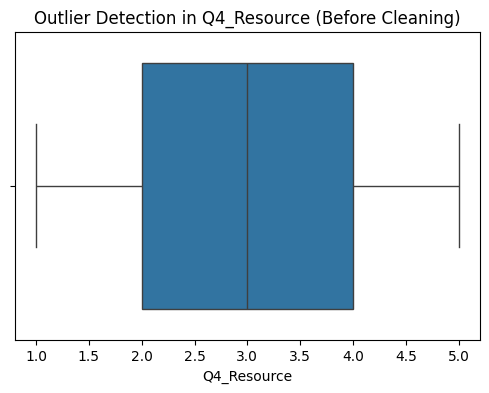

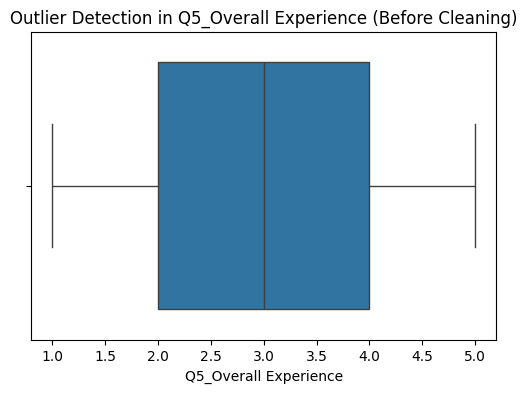

In [11]:
# -------------------------------
# 3. Outliers
# -------------------------------

numeric_cols = df.select_dtypes(include=['float64','int64']).columns

# Before Cleaning
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Detection in {col} (Before Cleaning)")
    plt.show()

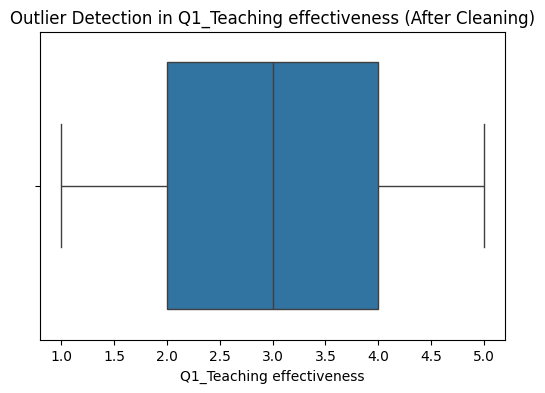

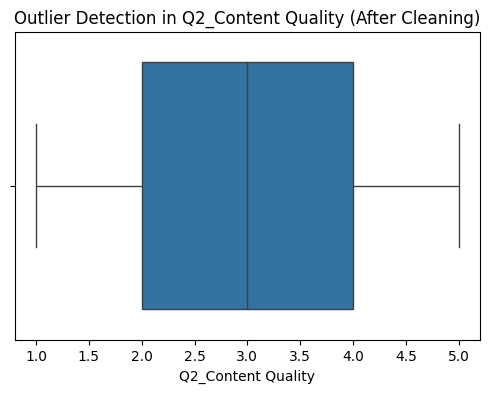

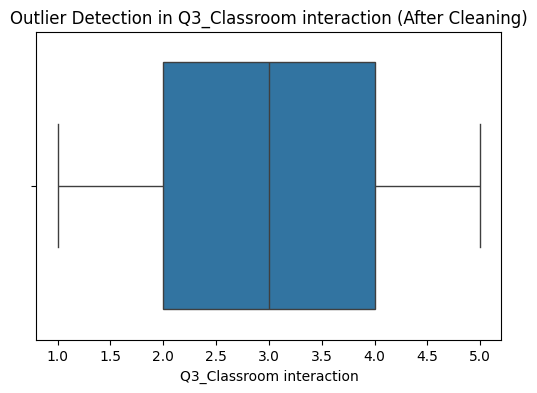

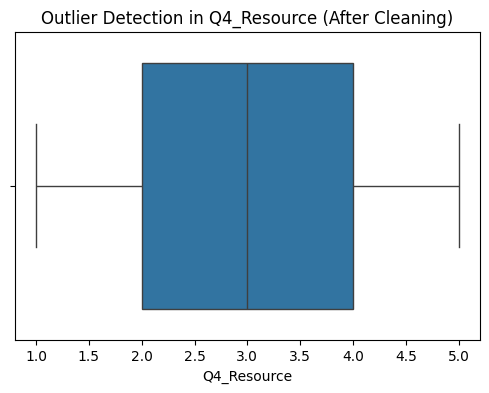

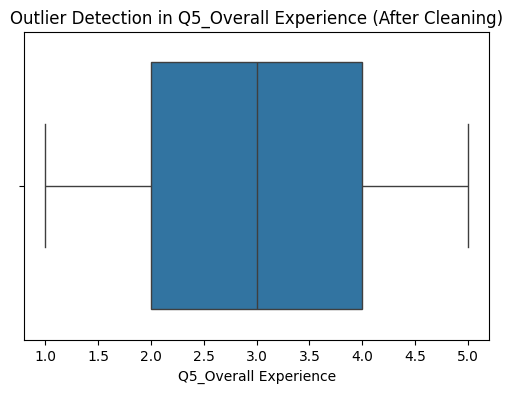

In [12]:
# After Cleaning
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_clean[col])
    plt.title(f"Outlier Detection in {col} (After Cleaning)")
    plt.show()